# Decision Tree
### Decision Tree : Dataset is split on the basic of some condition on features
### Entropy it measures the degree of impurity: Sigma_1_C(- p_i.log_2(pi))  max=1
### Gini Impurity it measures the likelihood of a random element being misclassified in a dataset : Sigma_1_C( -(p_i)^2 ) max=0.5 (binary classification)
### Information Gain : IG a measure to observe reduction in entropy to decide on which feature to split on=> IG = H(S) - Sigma_v_A([|S_v|/|S|].H(S_v))
### Gini Gain : Similar to IG formla too same : GG = Entropy of parent - Sumation of weighted entropy of children
### Pruning : is a technique used in DT to remove parts of the tree that are necessary in order to reduce overfitting and improve performance on unseen data.


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

titanicdf = sns.load_dataset("titanic")
titanicdf

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [2]:
titanicdf.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
titanicdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
titanicdf.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"] 

In [6]:
imp_mean = SimpleImputer(strategy="mean")
titanicdf[["age"]] = imp_mean.fit_transform(titanicdf[["age"]])

imp_mode = SimpleImputer(strategy="most_frequent")
titanicdf[["embarked"]] = imp_mode.fit_transform(titanicdf[["embarked"]])

titanicdf.isnull().sum()


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanicdf

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [8]:
le = LabelEncoder()
titanicdf["sex"] = le.fit_transform(titanicdf["sex"])
titanicdf.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore" )
encoded = ohe.fit_transform(titanicdf[["embarked"]])
encoded

array([[0., 1.],
       [0., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 0.],
       [1., 0.]], shape=(891, 2))

In [10]:
ohe.get_feature_names_out()

array(['embarked_Q', 'embarked_S'], dtype=object)

In [11]:
encodeddf = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(),
    index = titanicdf.index
)
print(type(encodeddf.columns[0]))
print(type(encodeddf["embarked_Q"]))

encodeddf

<class 'str'>
<class 'pandas.core.series.Series'>


,embarked_Q,embarked_S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
886,0.0,1.0
887,0.0,1.0
888,0.0,1.0
889,0.0,0.0


In [12]:
df = pd.concat([titanicdf, encodeddf], axis=1)
# df = df.drop(columns=["embarked", ], axis=1)
print(type(df["embarked_Q"]))
df

<class 'pandas.core.series.Series'>


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,embarked_Q,embarked_S
0,0,3,1,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.0,1.0
1,1,1,0,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.0,0.0
2,1,3,0,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.0,1.0
3,1,1,0,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.0,1.0
4,0,3,1,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,0.0,1.0
887,1,1,0,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0.0,1.0
888,0,3,0,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,0.0,1.0
889,1,1,1,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,0.0,0.0


In [13]:
features = ["pclass", "sex", "fare", "age", "embarked_Q", "embarked_S"]
X = df[features]
y = df[target]
X.head()
# y.head()

,pclass,sex,fare,age,embarked_Q,embarked_S
0,3,1,7.2500,22.0,0.0,1.0
1,1,0,71.2833,38.0,0.0,0.0
2,3,0,7.9250,26.0,0.0,1.0
3,1,0,53.1000,35.0,0.0,1.0
4,3,1,8.0500,35.0,0.0,1.0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 ,random_state=42)
X_train.head()
# y_test.head()

,pclass,sex,fare,age,embarked_Q,embarked_S
445,1,1,81.8583,4.000000,0.0,1.0
650,3,1,7.8958,29.699118,0.0,1.0
172,3,0,11.1333,1.000000,0.0,1.0
450,2,1,27.7500,36.000000,0.0,1.0
314,2,1,26.2500,43.000000,0.0,1.0


In [15]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred = model.predict(X_test)
print("Accuracy Score : ", accuracy_score(y_test, y_pred))

Accuracy Score :  0.753731343283582


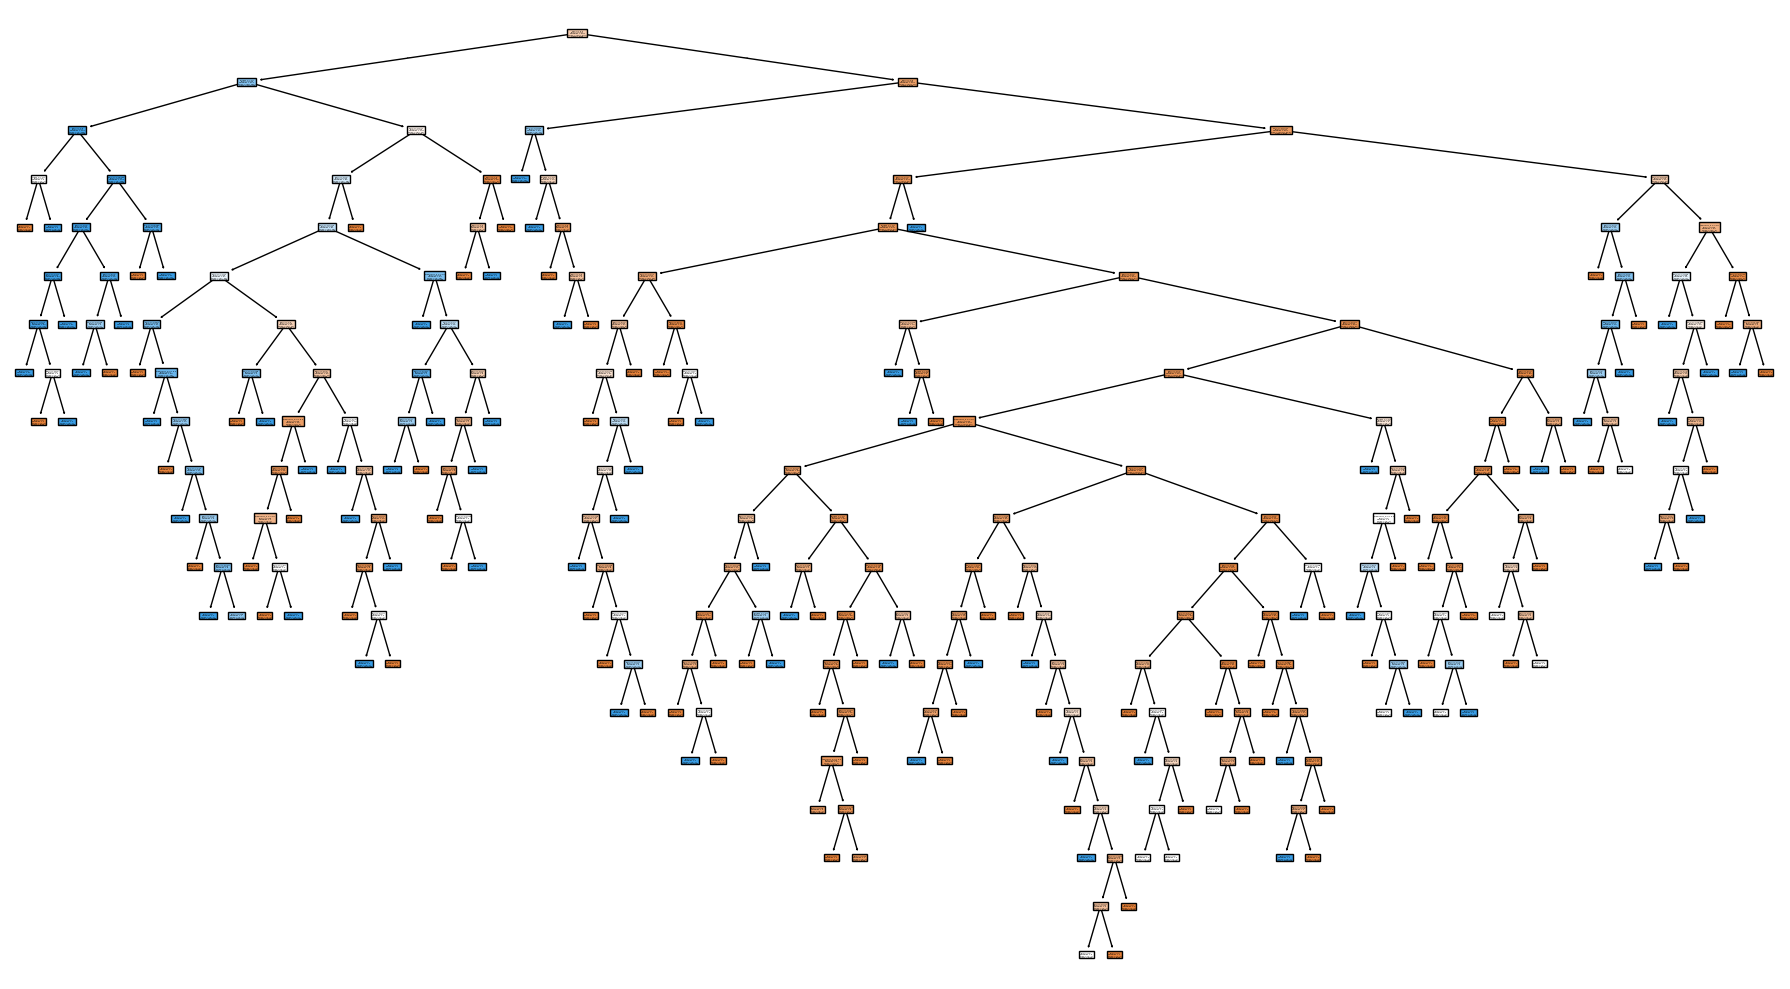

In [17]:
plt.figure(figsize=(18,10))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True  
)

plt.tight_layout()
plt.show()


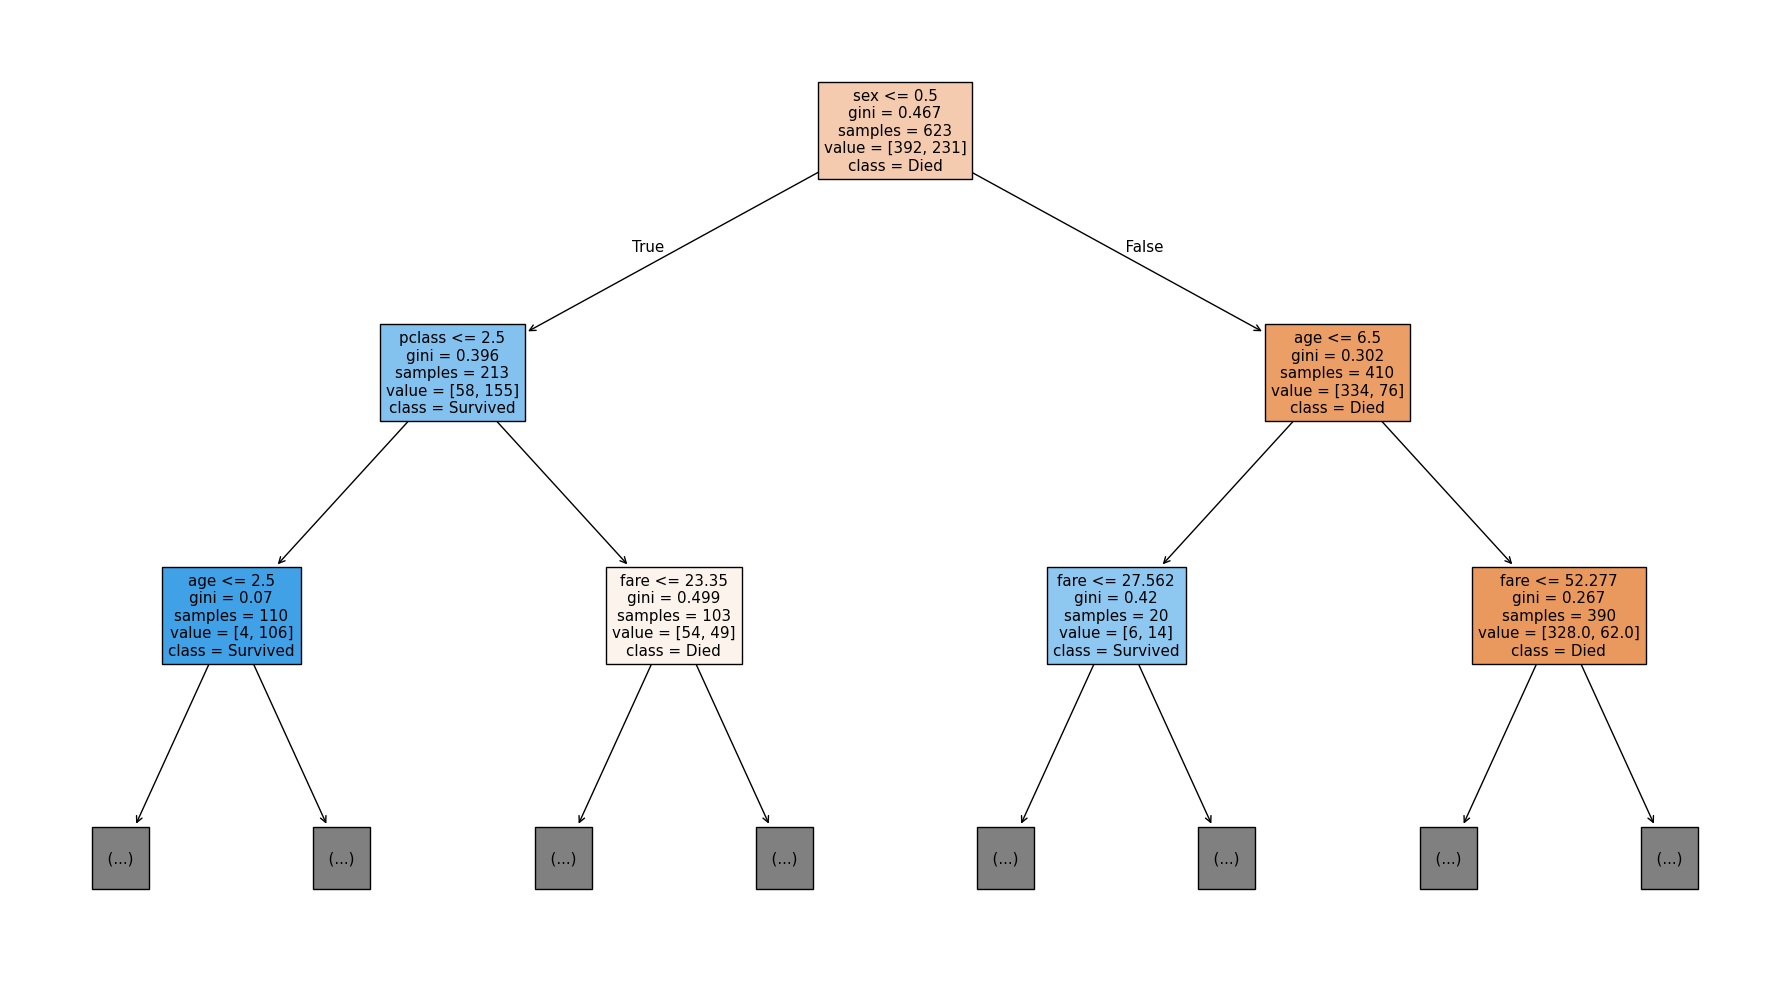

In [18]:
plt.figure(figsize=(18,10))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()


In [19]:
max_depths = [2,3,4,5,6,7,8,9,10]
for depth in max_depths :
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"At depth {depth} Accuracy is : {accuracy_score(y_test, y_pred)}")

At depth 2 Accuracy is : 0.7723880597014925
At depth 3 Accuracy is : 0.8059701492537313
At depth 4 Accuracy is : 0.8246268656716418
At depth 5 Accuracy is : 0.7947761194029851
At depth 6 Accuracy is : 0.7873134328358209
At depth 7 Accuracy is : 0.8022388059701493
At depth 8 Accuracy is : 0.7985074626865671
At depth 9 Accuracy is : 0.7798507462686567
At depth 10 Accuracy is : 0.7873134328358209


In [20]:
min_samples_splits = [3, 5, 10, 15, 20, 25, 30]
for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"With min sample split as {split} Accuracy Score : {accuracy_score(y_test, y_pred)}")
    

With min sample split as 3 Accuracy Score : 0.8246268656716418
With min sample split as 5 Accuracy Score : 0.8246268656716418
With min sample split as 10 Accuracy Score : 0.8246268656716418
With min sample split as 15 Accuracy Score : 0.8171641791044776
With min sample split as 20 Accuracy Score : 0.8171641791044776
With min sample split as 25 Accuracy Score : 0.8208955223880597
With min sample split as 30 Accuracy Score : 0.8208955223880597


In [24]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 3.82175342e-05, 1.14652603e-04,
       1.71978904e-04, 2.29305205e-04, 3.21027287e-04, 4.01284109e-04,
       4.84088767e-04, 5.35045479e-04, 5.35045479e-04, 5.35045479e-04,
       6.42054575e-04, 8.56072766e-04, 9.36329588e-04, 9.63081862e-04,
       9.63081862e-04, 9.63081862e-04, 9.63081862e-04, 1.04193067e-03,
       1.04779740e-03, 1.07009096e-03, 1.15926520e-03, 1.20385233e-03,
       1.23472034e-03, 1.25353512e-03, 1.33761370e-03, 1.35290071e-03,
       1.37364717e-03, 1.37583123e-03, 1.37583123e-03, 1.42678794e-03,
       1.44145476e-03, 1.49812734e-03, 1.50481541e-03, 1.51596219e-03,
       1.52065557e-03, 1.52183958e-03, 1.52487961e-03, 1.60513644e-03,
       1.67201712e-03, 1.71214553e-03, 1.85482433e-03, 1.95673775e-03,
       1.99750312e-03, 2.04211549e-03, 2.26056715e-03, 2.28286071e-03,
       2.33474391e-03, 2.40770465e-03, 2.63291575e-03, 2.78605824e-03,
       2.80169269e-03, 2.84379161e-03, 2.88924559e-03, 3.02412163e-03,
      

In [33]:
trees =[]

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append((model, alpha))

trees[:5]

[(DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=42),
  np.float64(0.0)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=42),
  np.float64(0.0)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(3.8217534204693614e-05),
                         random_state=42),
  np.float64(3.8217534204693614e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(0.00011465260261407824),
                         random_state=42),
  np.float64(0.00011465260261407824)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(0.00017197890392111996),
                         random_state=42),
  np.float64(0.00017197890392111996))]

In [38]:
best_alpha=0
best_score=-1
for model, alpha in trees:
    y_pred = model.predict(X_test)
    # model.score matches 
    score = model.score(X_test, y_test)
    if score>best_score:
        best_score=score
        best_alpha=alpha

print(f"Best Alpha : {best_alpha}")
print(f"Best Score : {best_score}")

Best Alpha : 0.0015159621901194938
Best Score : 0.8097014925373134


In [47]:
final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha, max_depth=4, min_samples_split=10)
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

0.8246268656716418

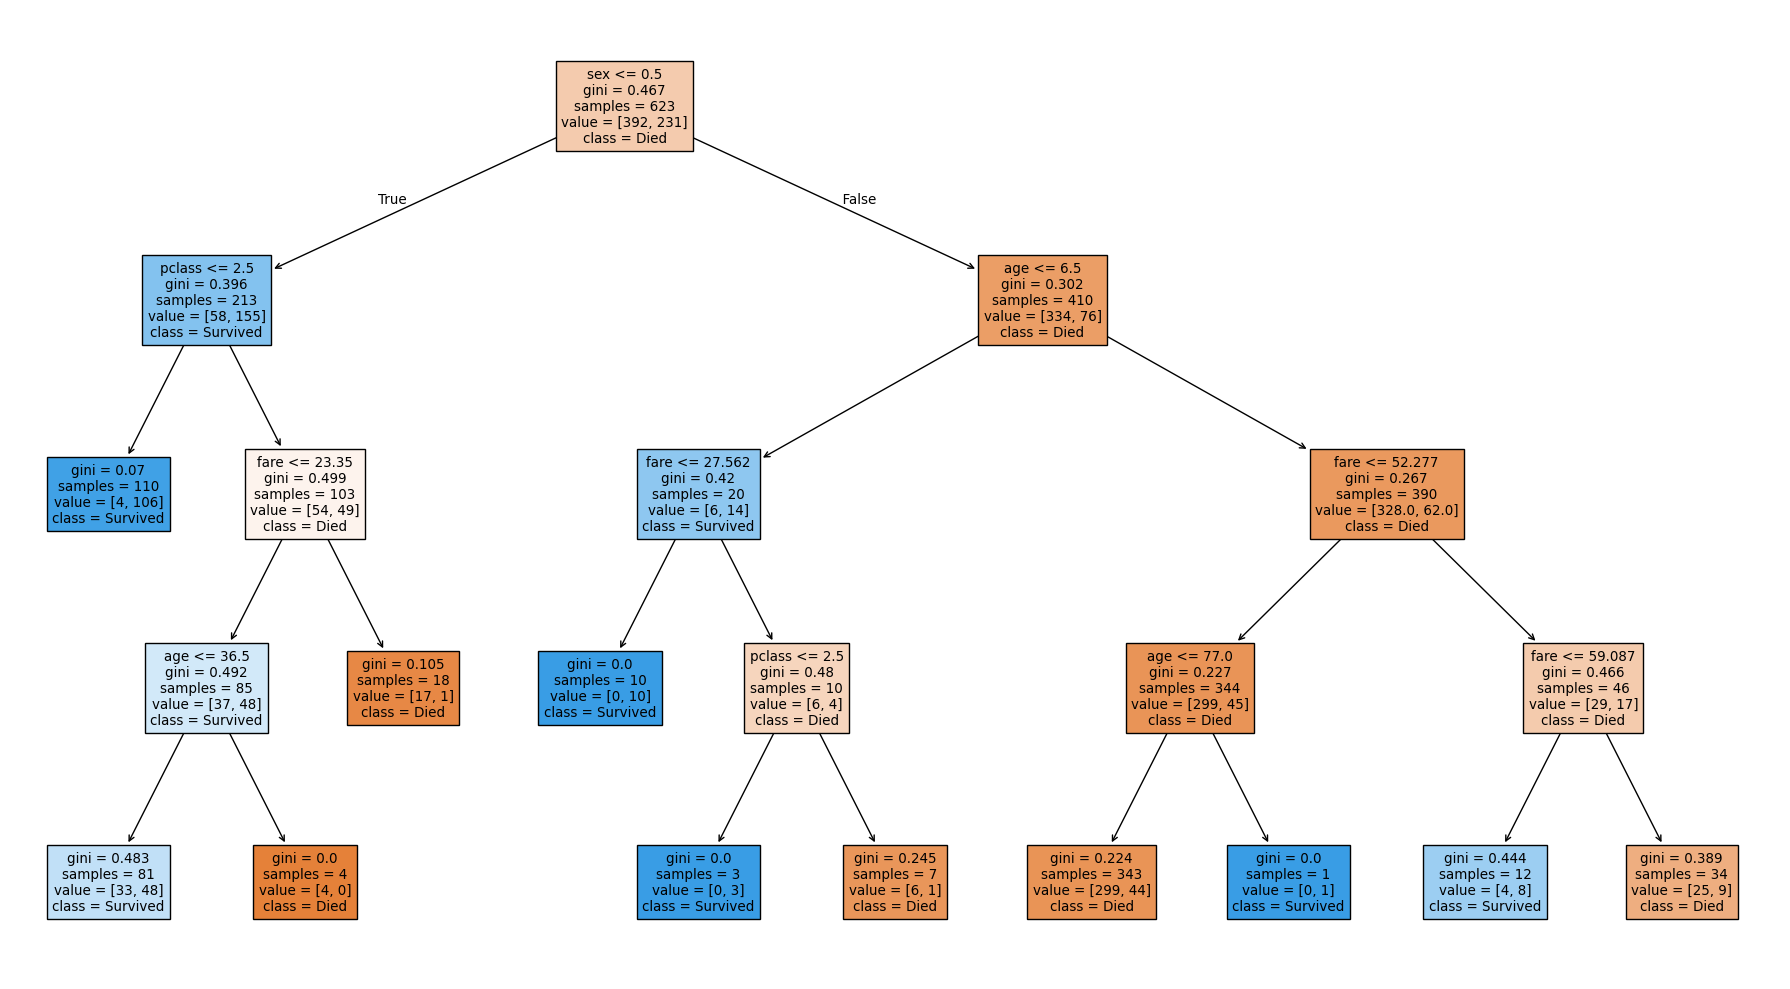

In [48]:
plt.figure(figsize=(18, 10))
plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

## Variance Reduction = Parent_Variance - Weighted Child_Variance
### VR = V_s - [ (|S_l|/|S|).V_l + (|S_r|/|S|).V_r ]
- var = 1/n. Sigma_1_n[y_i - yu]